In [46]:
# Run this cell first to import all necessary libraries for Part I
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn modules for preprocessing and modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, classification_report

# ISLP Dataset
from ISLP import load_data

# TensorFlow / Keras for Neural Networks
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Task 1

## Part I.A

In [47]:
# Load the datasets (Ensure CSV files are in the same directory)
train_df = pd.read_csv('/kaggle/input/datasets/mnassrib/telecom-churn-datasets/churn-bigml-80.csv')
test_df = pd.read_csv('/kaggle/input/datasets/mnassrib/telecom-churn-datasets/churn-bigml-20.csv')

# Display dimensions and variable types
print("Training Data Dimensions:", train_df.shape)
print("Testing Data Dimensions:", test_df.shape)
print("\nData Types for Training Data:\n", train_df.dtypes)

# Provide summary statistics
display(train_df.describe()) # If not using Jupyter, change 'display' to 'print'

Training Data Dimensions: (2666, 20)
Testing Data Dimensions: (667, 20)

Data Types for Training Data:
 State                      object
Account length              int64
Area code                   int64
International plan         object
Voice mail plan            object
Number vmail messages       int64
Total day minutes         float64
Total day calls             int64
Total day charge          float64
Total eve minutes         float64
Total eve calls             int64
Total eve charge          float64
Total night minutes       float64
Total night calls           int64
Total night charge        float64
Total intl minutes        float64
Total intl calls            int64
Total intl charge         float64
Customer service calls      int64
Churn                        bool
dtype: object


,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641
std,39.563974,42.521018,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236
min,1.000000,408.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,415.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,510.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000


## Part I.B


In [48]:
def prepare_telecom_data(df):
    data = df.copy()
    
    # 1. Drop non-predictive identifiers
    cols_to_drop = ['State', 'Area code', 'Customer ID']
    data = data.drop(columns=[c for c in cols_to_drop if c in data.columns])
    
    # 2. Convert churn into binary (0 = No, 1 = Yes)
    # Handles boolean or string representations of True/False
    data['Churn'] = data['Churn'].astype(int) 
    
    # 3. Handle categorical variables using one-hot encoding
    data = pd.get_dummies(data, drop_first=True, dtype=int)
    
    return data

# Apply cleaning function to both datasets
train_clean = prepare_telecom_data(train_df)
test_clean = prepare_telecom_data(test_df)

# Prepare feature matrices (X) and target vectors (y)
X_train = train_clean.drop('Churn', axis=1)
y_train = train_clean['Churn']

X_test = test_clean.drop('Churn', axis=1)
y_test = test_clean['Churn']

print("Prepared Training Features Shape:", X_train.shape)
print("Prepared Testing Features Shape:", X_test.shape)

Prepared Training Features Shape: (2666, 17)
Prepared Testing Features Shape: (667, 17)


## Part II

/tmp/ipykernel_57/3043022898.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=train_clean, palette='Set2')


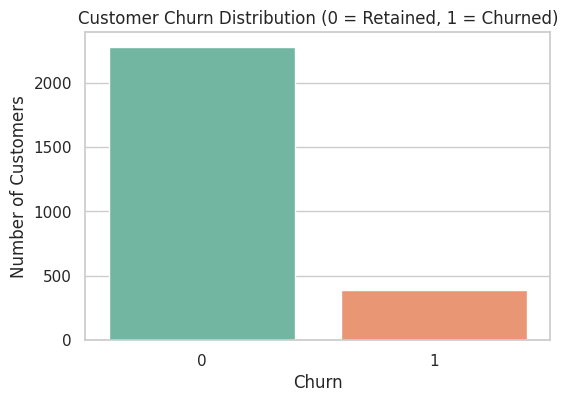

Overall Churn Rate in Training Data: 14.55%


In [49]:
# Set visual style
sns.set_theme(style="whitegrid")

# 1. Churn Rate Analysis (Class Imbalance)
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=train_clean, palette='Set2')
plt.title('Customer Churn Distribution (0 = Retained, 1 = Churned)')
plt.ylabel('Number of Customers')
plt.show()

# Calculate and print exact imbalance
churn_rate = y_train.mean() * 100
print(f"Overall Churn Rate in Training Data: {churn_rate:.2f}%")

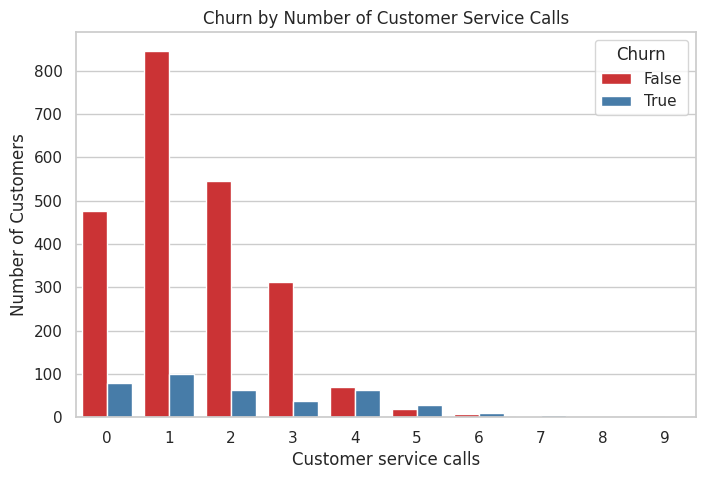

In [50]:
# 2. Distribution of important variables (Customer Service Calls)
plt.figure(figsize=(8, 5))
# Using train_df here so we can see the original categorical labels before one-hot encoding
sns.countplot(x='Customer service calls', hue='Churn', data=train_df, palette='Set1')
plt.title('Churn by Number of Customer Service Calls')
plt.ylabel('Number of Customers')
plt.show()

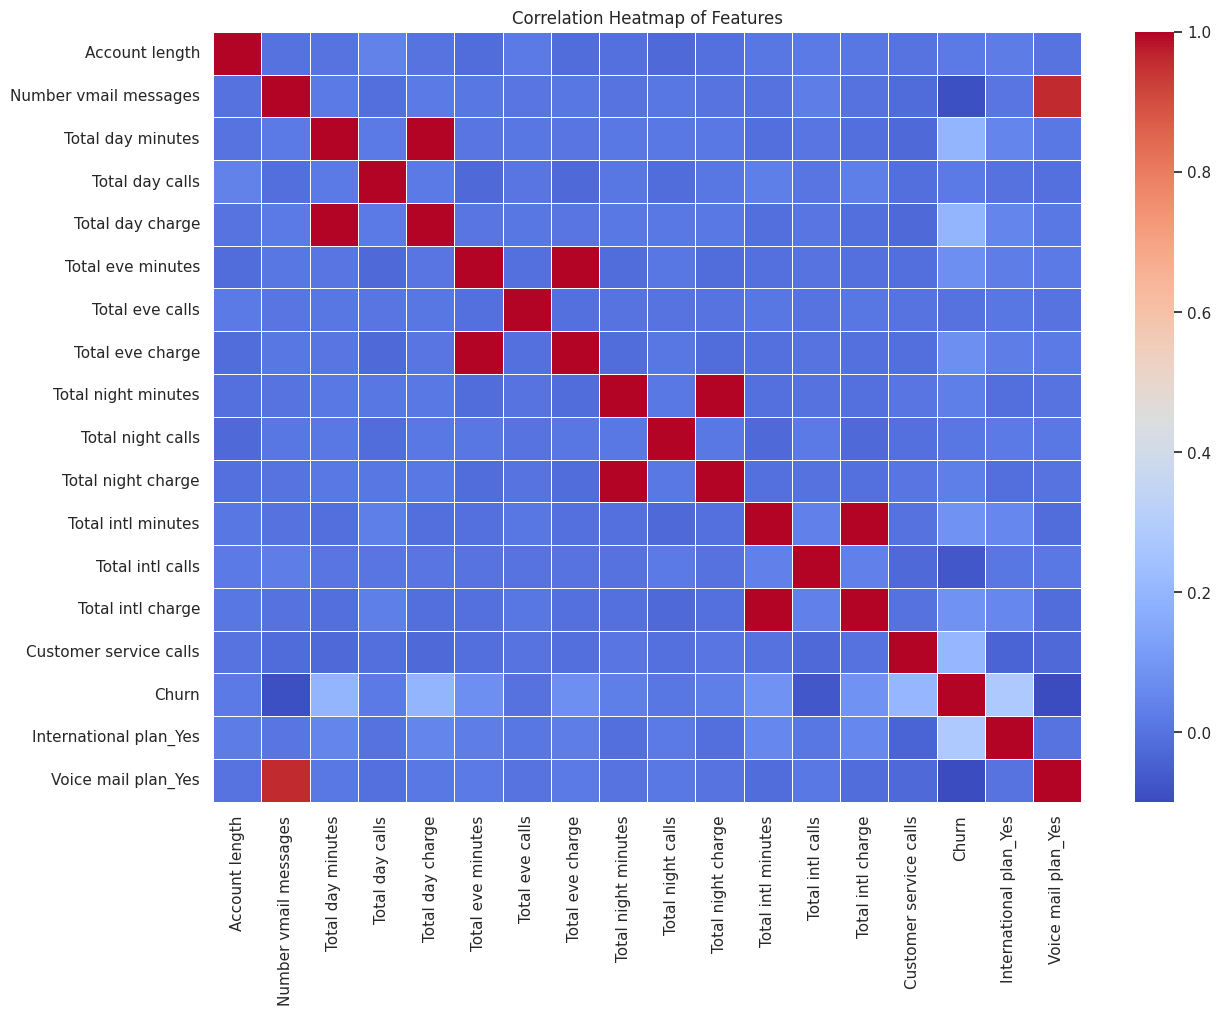

In [51]:
# 3. Correlation Analysis among numerical variables
plt.figure(figsize=(14, 10))

# Compute correlation matrix
corr_matrix = train_clean.corr()

# Create a heatmap
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Features')
plt.show()

## Part III


In [52]:
# Regression-based models require scaled data. Tree-based models do not.
# We will create a scaled version of our training and testing sets.

scaler = StandardScaler()

# Fit the scaler ONLY on the training data to prevent data leakage, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data successfully scaled for regression models.")

Data successfully scaled for regression models.


In [53]:
# Model 1: Logistic Regression (Requires Scaled Data)
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

# Predictions and Probabilities
y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation Metrics
print("--- Logistic Regression Evaluation ---")
print(classification_report(y_test, y_pred_log))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_log):.4f}")

--- Logistic Regression Evaluation ---
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       572
           1       0.47      0.19      0.27        95

    accuracy                           0.85       667
   macro avg       0.68      0.58      0.59       667
weighted avg       0.82      0.85      0.83       667

ROC-AUC Score: 0.8261


--- Random Forest Evaluation ---
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       572
           1       0.97      0.68      0.80        95

    accuracy                           0.95       667
   macro avg       0.96      0.84      0.89       667
weighted avg       0.95      0.95      0.95       667

ROC-AUC Score: 0.9241


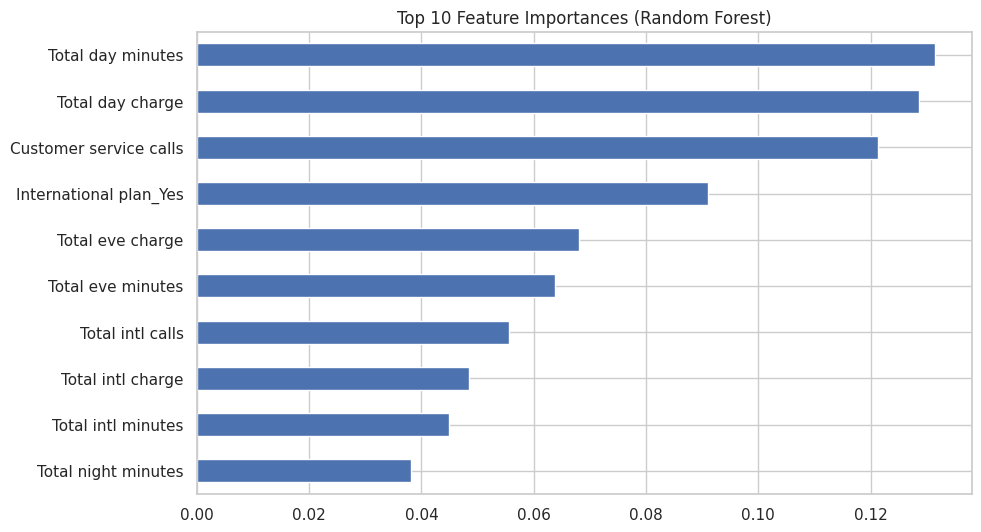

In [54]:
# Model 2: Random Forest (Can use unscaled data)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train) 

# Predictions and Probabilities
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluation Metrics
print("--- Random Forest Evaluation ---")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}")

# Feature Importance Visualization for Random Forest
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
feat_importances.nlargest(10).plot(kind='barh').invert_yaxis()
plt.title('Top 10 Feature Importances (Random Forest)')
plt.show()

## Part IV

# 1. Which model performed best and why

Between the models implemented, the Random Forest classifier clearly outperformed Logistic Regression.

Random Forest
Accuracy: 95%
Recall (churn): 0.68
ROC-AUC: 0.9241
Logistic Regression
Accuracy: 85%
Recall (churn): 0.19
ROC-AUC: 0.8261

The key difference lies in the model’s ability to correctly identify churned customers. While Logistic Regression achieved reasonable overall accuracy, it performed poorly in detecting actual churn cases (very low recall of 0.19). This is largely due to the class imbalance, where non-churn customers dominate the dataset.

In contrast, Random Forest significantly improved recall for churn (0.68), meaning it correctly identified a much larger proportion of customers at risk of leaving. Additionally, its higher ROC-AUC score indicates better overall discrimination between churn and non-churn customers.

This superior performance can be attributed to Random Forest’s ability to:

Capture nonlinear relationships
Handle feature interactions
Reduce overfitting through ensemble averaging

# 2. Bias-Variance Trade-off

The two models illustrate the bias-variance trade-off clearly:

Logistic Regression
High bias, low variance
Assumes a linear relationship between predictors and churn
Simpler and more stable, but underfits complex patterns
Random Forest
Lower bias, slightly higher variance
Combines multiple decision trees to reduce variance
Captures complex and nonlinear patterns in the data

In this case, Logistic Regression suffers from underfitting, failing to capture the complexity of customer behavior. Random Forest achieves a better balance by reducing bias while controlling variance through averaging across trees.

# 3. Interpretability vs Predictive Performance

There is a clear trade-off between interpretability and performance:

Logistic Regression
Highly interpretable
Coefficients directly indicate how features influence churn
Easier to explain to business stakeholders
Random Forest
Less interpretable (black-box model)
Provides feature importance, but not exact relationships
More difficult to explain individual predictions

In this project:

Logistic Regression is useful for understanding drivers of churn
Random Forest is better for accurate prediction

A practical approach in industry is to:

Use Random Forest (or similar models) for prediction
Use simpler models or feature importance for explanation

# 4. Real-World Applications in Telecommunications

Predictive churn models are extremely valuable in the telecommunications industry, where acquiring new customers is significantly more expensive than retaining existing ones.

From the analysis, key predictors of churn include:

Total day usage and charges
Customer service calls
International plan subscription

These insights allow telecom companies to better understand customer behavior and proactively address issues.

# 5. Business Applications
a. Customer Retention

Churn prediction models enable companies to:

Identify high-risk customers before they leave
Offer targeted interventions such as:
Discounts
Loyalty rewards
Personalized support

For example, customers with high service call frequency could be flagged for immediate follow-up, as they are more likely to churn.

b. Targeted Marketing

Instead of applying broad marketing strategies, companies can:

Focus resources on customers most likely to churn
Design personalized offers based on usage patterns

For instance:

High-usage customers may receive premium plans
International plan users may receive discounted international rates

This leads to more efficient marketing spending and higher conversion rates.

c. Service Improvement

The model highlights operational weaknesses:

High churn among customers with many service calls suggests customer dissatisfaction

Telecom companies can:

Improve customer support systems
Reduce wait times
Enhance issue resolution processes

By addressing these pain points, companies can reduce churn at the root cause, rather than reacting after customers leave.


Overall, the Random Forest model provides the best predictive performance, making it the preferred choice for deployment. However, combining its predictive strength with the interpretability of simpler models offers the most practical and effective solution in real-world applications.

# Task 2

## Part I.A


In [55]:
# Load the Default dataset from ISLP
Default = load_data('Default')

# Display dimensions and variable types
print("Default Dataset Dimensions:", Default.shape)
print("\nData Types:\n", Default.dtypes)

# Provide summary statistics
print("\nSummary Statistics:")
display(Default.describe(include='all')) # 'include=all' helps see categorical counts

Default Dataset Dimensions: (10000, 4)

Data Types:
 default    category
student    category
balance     float64
income      float64
dtype: object

Summary Statistics:


,default,student,balance,income
count,10000,10000,10000.000000,10000.000000
unique,2,2,NaN,NaN
top,No,No,NaN,NaN
freq,9667,7056,NaN,NaN
mean,NaN,NaN,835.374886,33516.981876
std,NaN,NaN,483.714985,13336.639563
min,NaN,NaN,0.000000,771.967729
25%,NaN,NaN,481.731105,21340.462903
50%,NaN,NaN,823.636973,34552.644802
75%,NaN,NaN,1166.308386,43807.729272


## Part I.B


In [56]:
# 1. Encode categorical variables ('default' and 'student') into binary integers
# 'No' -> 0, 'Yes' -> 1
Default['default'] = Default['default'].map({'No': 0, 'Yes': 1})
Default['student'] = Default['student'].map({'No': 0, 'Yes': 1})

# Define features (X) and response variable (y)
X = Default[['student', 'balance', 'income']]
y = Default['default']

# 2. Perform train-test splitting (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Standardize/normalize predictors
# We only scale the continuous variables ('balance' and 'income'). 
# It's best practice to leave the binary 'student' indicator as 0/1.
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[['balance', 'income']] = scaler.fit_transform(X_train[['balance', 'income']])
X_test_scaled[['balance', 'income']] = scaler.transform(X_test[['balance', 'income']])

print("Data successfully encoded, split, and standardized.")

Data successfully encoded, split, and standardized.


## Part II

In [57]:
# A. Model Construction
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

# B. Performance Evaluation
y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("--- Logistic Regression Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

--- Logistic Regression Performance ---
Accuracy: 0.9730
ROC-AUC: 0.9485

Confusion Matrix:
[[1925    8]
 [  46   21]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1933
           1       0.72      0.31      0.44        67

    accuracy                           0.97      2000
   macro avg       0.85      0.65      0.71      2000
weighted avg       0.97      0.97      0.97      2000



## Part III

In [59]:
X_train_scaled = np.asarray(X_train_scaled).astype('float32')
X_test_scaled = np.asarray(X_test_scaled).astype('float32')
y_train = np.asarray(y_train).astype('float32')
y_test = np.asarray(y_test).astype('float32')

In [60]:
# A. Neural Network Architecture
# Setting a random seed for reproducibility
tf.random.set_seed(42)

nn_model = Sequential([
    # Input layer and Single Hidden Layer with 10 units
    # Activation: 'relu' (Rectified Linear Unit) helps the network learn non-linear patterns efficiently
    Dense(10, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    
    # Dropout Regularization
    # Purpose: Randomly ignores 20% of neurons during training to prevent the model from memorizing the training data (overfitting)
    Dropout(0.2),
    
    # Output Layer
    # Activation: 'sigmoid' maps the output to a probability between 0 and 1 (perfect for binary classification)
    Dense(1, activation='sigmoid')
])

# Compile the model
nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print(nn_model.summary())

# B. Model Training
# We use a validation split during training to monitor for overfitting
history = nn_model.fit(
    X_train_scaled, y_train, 
    epochs=50, 
    batch_size=32, 
    validation_split=0.2, 
    verbose=0 # Set to 1 if you want to see the progress bar for each epoch
)

print("\nNeural Network training complete.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 10)             │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

None

Neural Network training complete.


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
--- Neural Network Performance ---
Accuracy: 0.9725
ROC-AUC: 0.9473

Confusion Matrix:
[[1924    9]
 [  46   21]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99      1933
         1.0       0.70      0.31      0.43        67

    accuracy                           0.97      2000
   macro avg       0.84      0.65      0.71      2000
weighted avg       0.97      0.97      0.97      2000



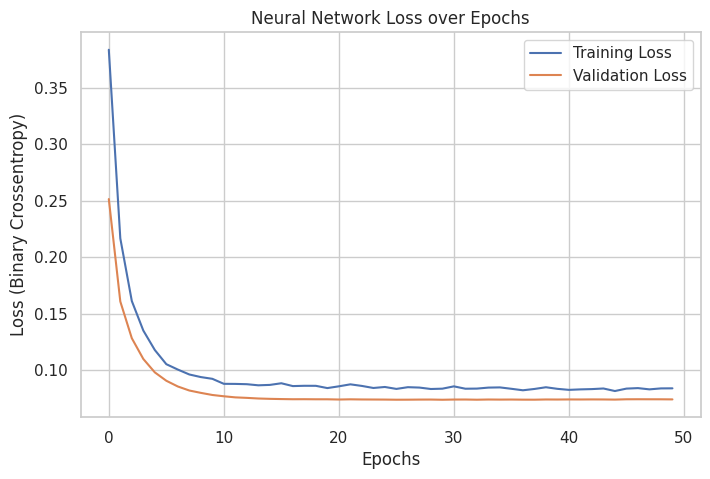

In [61]:
# Evaluate the Neural Network on the Test Set
y_prob_nn = nn_model.predict(X_test_scaled)
# Convert probabilities to binary predictions (threshold = 0.5)
y_pred_nn = (y_prob_nn > 0.5).astype(int)

print("--- Neural Network Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nn):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_nn):.4f}\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nn))

# Plotting Training vs Validation Loss to discuss overfitting/underfitting
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Neural Network Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss (Binary Crossentropy)')
plt.legend()
plt.show()

# IV. Comparative Analysis and Interpretation (8 points)
Discuss:

Both Logistic Regression and the Neural Network achieved very strong performance in predicting credit card default. Logistic Regression slightly outperformed the Neural Network, achieving an accuracy of 97.30% and ROC-AUC of 0.9485, compared to the Neural Network’s 97.25% accuracy and 0.9473 ROC-AUC.

Logistic Regression performed well because the dataset contains only a few predictors and relatively simple relationships. Its main advantage is interpretability, since the coefficients clearly show how variables influence default probability. However, it is limited in capturing complex nonlinear patterns.

The Neural Network is more flexible and capable of learning nonlinear relationships automatically. However, it is more computationally expensive and behaves like a “black-box” model, making interpretation more difficult.

Dropout regularization helped prevent overfitting in the Neural Network by randomly disabling neurons during training. The training and validation loss curves remained close throughout training, indicating that the model generalized well to unseen data.

Overall, Logistic Regression provided the best balance between predictive performance, simplicity, and interpretability for this dataset.